In [17]:
import numpy as np
import torch
import torch.nn as nn

In [2]:
import yaml

with open("coco.yaml", "r") as f:
    model_names = yaml.safe_load(f)
    model_names = dict(enumerate(model_names["names"]))

In [15]:
model = torch.load(
    "yolo26n.pth",
    map_location="cpu",
    weights_only=False,
).eval()

if getattr(model, "end2end", False):
    model.set_head_attr(max_det=300, agnostic_nms=False)

model = model.fuse(verbose=False).to("cuda:0")
model.float()

for p in model.parameters():
    p.requires_grad_(False)

In [22]:
torch.save(model, "yolo26-complete.pth")

In [23]:
model = torch.load(
    "yolo26-complete.pth",
    map_location="cpu",
    weights_only=False,
).eval().to("cuda:0")

### Test

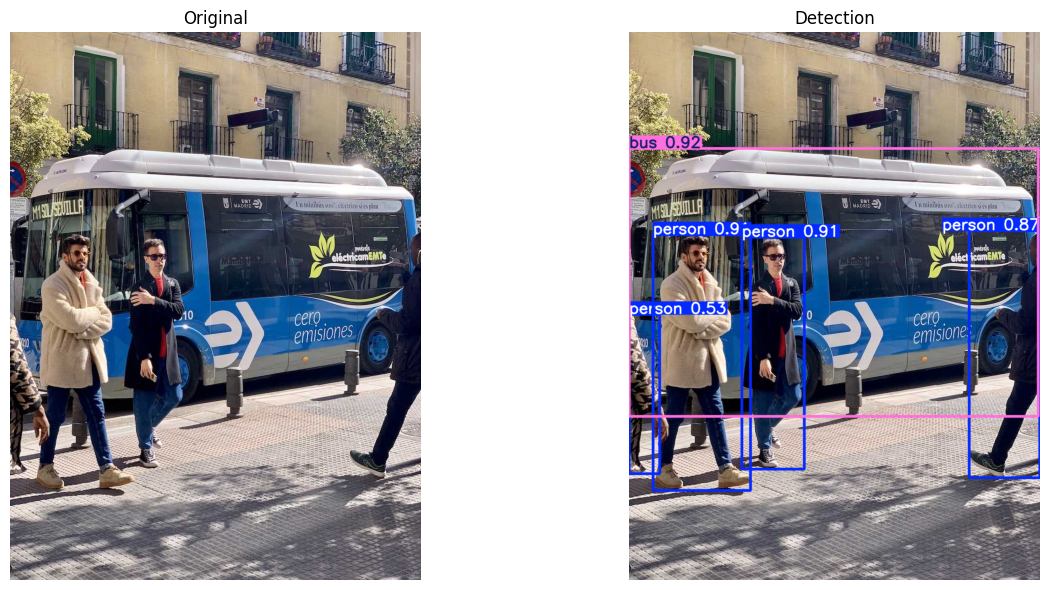

In [24]:
# Preprocess
import cv2
import matplotlib.pyplot as plt
import numpy as np
from ultralytics.data.augment import LetterBox
import torch

def preprocess(im: torch.Tensor | list[np.ndarray]) -> torch.Tensor:
    not_tensor = not isinstance(im, torch.Tensor)
    if not_tensor:
        im = np.stack(pre_transform(im))
        if im.shape[-1] == 3:
            im = im[..., ::-1]  # BGR to RGB
        im = im.transpose((0, 3, 1, 2))  # BHWC to BCHW, (n, 3, h, w)
        im = np.ascontiguousarray(im)  # contiguous
        im = torch.from_numpy(im)

    im = im.to(device)
    im = im.half() if model_fp16 else im.float()  # uint8 to fp16/32
    if not_tensor:
        im /= 255  # 0 - 255 to 0.0 - 1.0
    return im

def pre_transform(im: list[np.ndarray]) -> list[np.ndarray]:
    letterbox = LetterBox(
        (640, 640),
        auto=len({x.shape for x in im}) == 1,
        stride=32,
    )
    return [letterbox(image=x) for x in im]

device = "cuda:0"
model_fp16 = False
image_path = "bus.jpg"

img = cv2.imread(image_path)
img = np.array([img])
im = preprocess(img)

# Inference
with torch.no_grad():
    y = model(
        im,
        # augment=False,
        # visualize=False,
        # embed=None,
    )
    
preds = list(y)

# Post Process
import torch
from ultralytics.engine.results import Results
from ultralytics.utils import nms, ops
import cv2
import matplotlib.pyplot as plt
import yaml

with open("coco.yaml", "r") as f:
    model_names = yaml.safe_load(f)
    model_names = dict(enumerate(model_names["names"]))

def postprocess(preds, img, orig_imgs):
    args_conf = 0.25
    args_iou = 0.7
    args_classes = None
    args_agnostic_nms = False
    args_max_det = 300
    args_task = "detect"
    
    save_feats = None
    model_names_length = 80
    
    preds = nms.non_max_suppression(
        preds,
        args_conf,
        args_iou,
        args_classes,
        args_agnostic_nms,
        max_det=args_max_det,
        nc=0 if args_task == "detect" else model_names_length,
        end2end=True,
        rotated=args_task == "obb",
        return_idxs=save_feats,
    )
    
    results = construct_results(preds, img, orig_imgs)
    return results

def construct_results(preds, img, orig_imgs):
    source = 'image_path'
    return [
        construct_result(pred, img, orig_img, img_path)
        for pred, orig_img, img_path in zip(preds, orig_imgs, source)
    ]

def construct_result(pred, img, orig_img, img_path):
    pred[:, :4] = ops.scale_boxes(img.shape[2:], pred[:, :4], orig_img.shape)
    return Results(orig_img, path=img_path, names=model_names, boxes=pred[:, :6])

results = postprocess(preds, im, img)

original = cv2.cvtColor(results[0].orig_img, cv2.COLOR_BGR2RGB)
predicted = cv2.cvtColor(results[0].plot(), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(predicted)
plt.title("Detection")
plt.axis("off")

plt.tight_layout()
plt.show()